In [6]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)
pd.set_option("display.width", 160)

sns.set_theme(style="whitegrid", context="notebook")

DATA = Path("../data/processed")
CASES_PATH = DATA / "cases_v4_full_merged.csv"

df = pd.read_csv(CASES_PATH)

print(f"Loaded {CASES_PATH}")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")

Loaded ../data/processed/cases_v4_full_merged.csv
Rows: 1,075
Columns: 247


In [7]:
df.head()

,country,iso3,year,dj_expression,dj_expression_lag1,dj_expression_lag2,wdj_expression,wdj_expression_lag1,wdj_expression_lag2,wdj_citizen,wdj_citizen_lag1,wdj_citizen_lag2,wdj_intermediaries,wdj_intermediaries_lag1,wdj_intermediaries_lag2,wdj_press,wdj_press_lag1,wdj_press_lag2,wdj_govprot,wdj_govprot_lag1,wdj_govprot_lag2,wdj_restriction,wdj_restriction_lag1,wdj_restriction_lag2,wdj_obligation,wdj_obligation_lag1,wdj_obligation_lag2,appeal_nonreg,appeal_nonreg_crisis,appeal_reg,appeal_reg_crisis,c_disinfo_gen,c_disinfo_gen_crisis,c_disinfo_gen_digi,c_disinfo_iccpr,c_disinfo_iccpr_crisis,c_disinfo_iccpr_digi,c_disinfo_noniccpr,c_disinfo_noniccpr_crisis,c_disinfo_noniccpr_digi,c_express_iccpr,c_express_iccpr_crisis,c_express_iccpr_digi,c_express_iccpr_govoff,c_express_noniccpr,c_express_noniccpr_crisis,c_express_noniccpr_digi,c_malinfo_gen,c_malinfo_gen_crisis,c_malinfo_gen_digi,c_misinfo_gen,c_misinfo_gen_crisis,c_misinfo_gen_digi,c_misinfo_iccpr,c_misinfo_iccpr_crisis,c_misinfo_iccpr_digi,c_misinfo_noniccpr,c_misinfo_noniccpr_crisis,c_misinfo_noniccpr_digi,exemption_leg,...,_merge,country_clean,country_name,country_text_id,country_id,v2x_polyarchy,v2x_polyarchy_lag1,v2x_polyarchy_lag2,v2x_freexp_altinf,v2x_freexp_altinf_lag1,v2x_freexp_altinf_lag2,v2x_freexp,v2x_freexp_lag1,v2x_freexp_lag2,v2x_jucon,v2x_jucon_lag1,v2x_jucon_lag2,v2jureform,v2jureform_lag1,v2jureform_lag2,v2jupurge,v2jupurge_lag1,v2jupurge_lag2,v2jupoatck,v2jupoatck_lag1,v2jupoatck_lag2,v2jupack,v2jupack_lag1,v2jupack_lag2,v2juaccnt,v2juaccnt_lag1,v2juaccnt_lag2,v2jucorrdc,v2jucorrdc_lag1,v2jucorrdc_lag2,v2juhcind,v2juhcind_lag1,v2juhcind_lag2,v2juncind,v2juncind_lag1,v2juncind_lag2,v2juhccomp,v2juhccomp_lag1,v2juhccomp_lag2,v2jucomp,v2jucomp_lag1,v2jucomp_lag2,v2jureview,v2jureview_lag1,v2jureview_lag2,vdem_matched,legal_system,v2juhcname,court_level,high_court,low_court,supranatl_court,j_ind,j_ind_lag1,j_ind_lag2
0,angola,AGO,2015,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,Matched (3),Angola,Angola,AGO,104,0.290,0.290,0.290,0.370,0.370,0.370,0.380,0.380,0.380,0.216,0.216,0.216,-0.157,-0.157,-0.157,-0.634,-0.702,-0.702,0.995,0.995,0.995,0.743,0.743,0.743,-0.726,-0.726,-0.726,-0.915,-0.915,-0.915,-1.210,-1.210,-1.210,0.217,0.217,0.217,-1.236,-1.236,-1.236,-1.067,-1.067,-1.067,1.462,1.462,1.462,True,Civil,Constitutional Court (Tribunal Constitucional),low,0,1,0,0.217,0.217,0.217
1,angola,AGO,2016,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,Matched (3),Angola,Angola,AGO,104,0.290,0.290,0.290,0.373,0.370,0.370,0.390,0.380,0.380,0.216,0.216,0.216,-0.157,-0.157,-0.157,-0.634,-0.634,-0.702,1.039,0.995,0.995,0.743,0.743,0.743,-0.726,-0.726,-0.726,-0.915,-0.915,-0.915,-1.210,-1.210,-1.210,0.217,0.217,0.217,-1.236,-1.236,-1.236,-1.067,-1.067,-1.067,1.462,1.462,1.462,True,Civil,Constitutional Court (Tribunal Constitucional),low,0,1,0,0.217,0.217,0.217
2,australia,AUS,1994,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,Matched (3),Australia,Australia,AUS,67,0.889,0.890,0.892,0.964,0.964,0.964,0.975,0.975,0.975,0.990,0.990,0.990,0.713,0.713,0.713,2.610,2.610,2.610,0.818,0.818,0.818,1.834,1.834,1.834,2.412,2.412,2.412,2.332,2.332,2.332,3.037,3.037,3.037,3.014,3.014,3.014,3.127,3.127,3.127,2.763,2.763,2.763,1.835,1.835,1.835,True,Common,High Court of Australia,high,1,0,0,3.037,3.037,3.037
3,australia,AUS,1998,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,Matched (3),Australia,Australia,AUS,67,0.882,0.882,0.891,0.964,0.964,0.964,0.975,0.975,0.975,0.990,0.990,0.990,0.713,0.713,0.713,2.610,2.610,2.610,

In [8]:
overview = pd.Series({
    "rows": len(df),
    "columns": df.shape[1],
    "countries": df["country"].nunique(dropna=True),
    "years": df["year"].nunique(dropna=True),
    "min_year": df["year"].min(),
    "max_year": df["year"].max(),
    "case_ids": df["case_id"].nunique(dropna=True),
    "duplicate_case_ids": df["case_id"].duplicated().sum(),
})

overview.to_frame("value")

,value
rows,1075
columns,247
countries,47
years,62
min_year,1927
max_year,2025
case_ids,1075
duplicate_case_ids,0


In [9]:
id_cols = ["country", "iso3", "year", "case_id", "case_name", "source_dataset"]
case_cols = [
    "decision_date_raw",
    "decision_direction",
    "judicial_body",
    "type_of_law",
    "theme",
    "mode_of_expression",
    "case_status",
    "case_significance",
    "case_number",
]
court_cols = ["court_level", "high_court", "low_court", "supranatl_court", "j_ind", "j_ind_lag1", "j_ind_lag2"]
vdem_cols = [c for c in df.columns if c.startswith("v2")]
dejure_cols = [c for c in df.columns if c.startswith(("dj_", "wdj_"))]
law_indicator_cols = [
    c for c in df.columns
    if c.startswith(("appeal_", "c_", "exemption_", "gov_", "im_", "i_", "lawsuit_", "press_", "p_", "reg_"))
]
text_cols = ["summary_outcome", "facts", "decision_overview", "authorities", "related_text"]

column_groups = pd.Series({
    "id_cols": len(id_cols),
    "case_cols": len(case_cols),
    "court_cols": len(court_cols),
    "vdem_cols": len(vdem_cols),
    "dejure_cols": len(dejure_cols),
    "law_indicator_cols": len(law_indicator_cols),
    "text_cols": len(text_cols),
})

column_groups.to_frame("n_columns")

,n_columns
id_cols,6
case_cols,9
court_cols,7
vdem_cols,46
dejure_cols,24
law_indicator_cols,136
text_cols,5


In [10]:
missing = (
    df.isna()
    .mean()
    .mul(100)
    .rename("missing_pct")
    .to_frame()
    .assign(missing_n=df.isna().sum())
    .sort_values("missing_pct", ascending=False)
)

missing.head(40)

,missing_pct,missing_n
decision_cited_in,90.046512,968
case_number,70.232558,755
related_text,69.116279,743
authorities,68.186047,733
corresponding_law_reference,67.906977,730
case_status,67.813953,729
case_name,67.627907,727
case_significance,67.627907,727
source_url,67.627907,727
ruling_judge,57.023256,613


In [11]:
def value_table(col, normalize=True, dropna=False):
    counts = df[col].value_counts(dropna=dropna, normalize=normalize)
    if normalize:
        counts = counts.mul(100).round(2)
    return counts.rename("pct" if normalize else "n").to_frame()


for col in ["source_dataset", "decision_direction", "court_level", "type_of_law", "theme", "mode_of_expression"]:
    display(col)
    display(value_table(col).head(20))

'source_dataset'

,pct
source_dataset,
old_judicial_decisions,67.63
new_cases_may_2026,32.37


'decision_direction'

,pct
decision_direction,
Expands Expression,56.37
Contracts Expression,22.42
Mixed Outcome,21.12
NaN,0.09


'court_level'

...

,pct
type_of_law,
Constitutional Law,25.95
Civil Law,13.21
Criminal Law,11.16
International/Regional Human Rights Law,9.30
Constitutional Law|Criminal Law,4.47
Administrative Law,4.00
Administrative Law|Constitutional Law,3.72
Civil Law|Constitutional Law,3.26
International Human Rights Law,2.98


'theme'

,pct
theme,
Defamation / Reputation,10.70
Access to Public Information,7.72
Political Expression,6.70
"Privacy, Data Protection and Retention",4.56
Freedom of Association and Assembly / Protests,4.37
Content Regulation / Censorship,2.42
Hate Speech,2.14
NaN,1.95
Violence Against Speakers / Impunity,1.86


'mode_of_expression'

,pct
mode_of_expression,
Electronic / Internet-based Communication,32.09
Press / Newspapers,17.67
Public Documents,9.49
Non-verbal Expression,9.49
Public Speech,6.60
Audio / Visual Broadcasting,5.67
Public Assembly,3.81
Books / Plays,2.51
Pamphlets / Posters / Banners,2.23


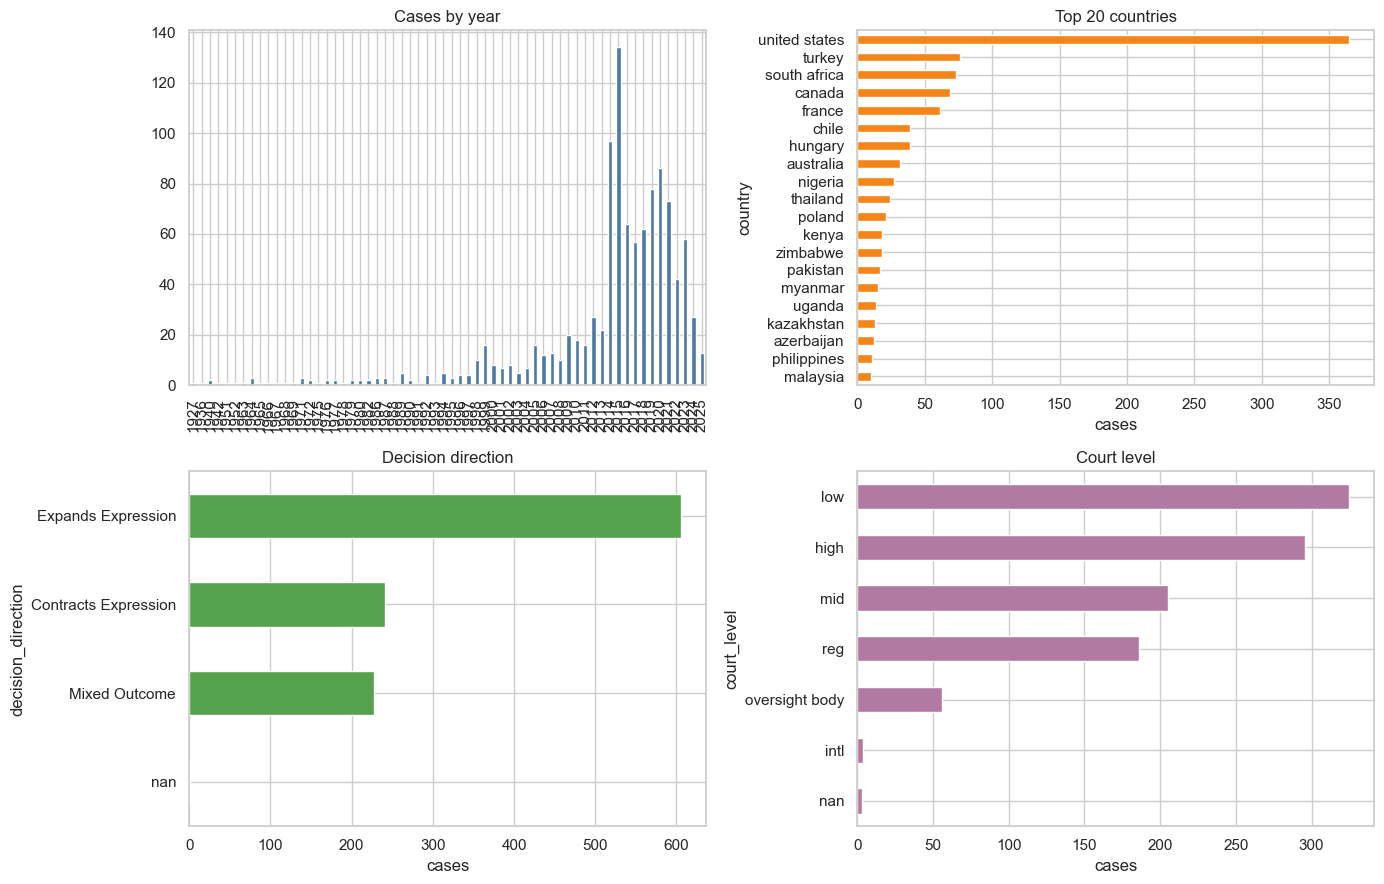

In [12]:
count_tables = {
    "cases_by_year": df["year"].value_counts().sort_index().rename("n").to_frame(),
    "top_20_countries": df["country"].value_counts().head(20).rename("n").to_frame(),
    "decision_direction": df["decision_direction"].value_counts(dropna=False).rename("n").to_frame(),
    "court_level": df["court_level"].value_counts(dropna=False).rename("n").to_frame(),
}

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

count_tables["cases_by_year"]["n"].plot(ax=axes[0, 0], kind="bar", color="#4C78A8")
axes[0, 0].set_title("Cases by year")
axes[0, 0].set_xlabel("")
axes[0, 0].tick_params(axis="x", labelrotation=90)

count_tables["top_20_countries"]["n"].sort_values().plot(ax=axes[0, 1], kind="barh", color="#F58518")
axes[0, 1].set_title("Top 20 countries")
axes[0, 1].set_xlabel("cases")

count_tables["decision_direction"]["n"].sort_values().plot(ax=axes[1, 0], kind="barh", color="#54A24B")
axes[1, 0].set_title("Decision direction")
axes[1, 0].set_xlabel("cases")

count_tables["court_level"]["n"].sort_values().plot(ax=axes[1, 1], kind="barh", color="#B279A2")
axes[1, 1].set_title("Court level")
axes[1, 1].set_xlabel("cases")

plt.tight_layout()

In [13]:
judicial_pressure_cols = ["v2jureform", "v2jupoatck", "v2jupack"]

judicial_pressure = df[judicial_pressure_cols].apply(pd.to_numeric, errors="coerce")

judicial_pressure_summary = (
    judicial_pressure
    .describe(percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
    .T
    .assign(
        missing_n=judicial_pressure.isna().sum(),
        missing_pct=judicial_pressure.isna().mean().mul(100).round(2),
    )
)

judicial_pressure_summary

,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,max,missing_n,missing_pct
v2jureform,1075.0,0.014281,0.928650,-3.321,-3.14338,-1.982,-1.2180,-0.159,0.056,0.455,0.9850,1.382,1.83800,3.077,0,0.0
v2jupoatck,1075.0,0.384115,1.243624,-4.259,-2.83018,-2.108,-1.2060,-0.350,0.634,1.175,1.9934,2.313,2.45944,2.621,0,0.0
v2jupack,1075.0,0.990465,1.188665,-3.131,-2.10000,-1.654,-1.0836,0.591,1.484,1.733,2.1570,2.157,2.15700,2.157,0,0.0


In [14]:
judicial_pressure_range_specs = {
    "v2jureform": [
        {
            "scale": 0,
            "low": -3.77,
            "high": -1.29,
            "label": "0: reduced via institutional reform",
        },
        {
            "scale": 1,
            "low": -1.29,
            "high": 1.24,
            "label": "1: no change via institutional review",
        },
        {
            "scale": 2,
            "low": 1.24,
            "high": 3.57,
            "label": "2: enhanced via institutional reform",
        },
    ],
    "v2jupoatck": [
        {"scale": 0, "low": -4.29, "high": -2.55, "label": "0: daily or weekly attacks"},
        {"scale": 1, "low": -2.55, "high": -1.56, "label": "1: common, nearly monthly attacks"},
        {"scale": 2, "low": -1.56, "high": -0.43, "label": "2: attacks occurred more than once"},
        {"scale": 3, "low": -0.43, "high": 0.84, "label": "3: rare attacks"},
        {"scale": 4, "low": 0.84, "high": 3.14, "label": "4: no attacks"},
    ],
    "v2jupack": [
        {"scale": 0, "low": -4.22, "high": -2.19, "label": "0: massive politically motivated increase"},
        {"scale": 1, "low": -2.19, "high": -1.22, "label": "1: limited increase on very important courts"},
        {"scale": 2, "low": -1.22, "high": -0.45, "label": "2: limited politically motivated increase"},
        {"scale": 3, "low": -0.45, "high": 2.16, "label": "3: no political packing / no increase"},
    ],
}

judicial_pressure_ranges = pd.DataFrame(
    [
        {
            "variable": variable,
            "survey_scale": spec["scale"],
            "estimate_low": spec["low"],
            "estimate_high": spec["high"],
            "range_label": spec["label"],
        }
        for variable, specs in judicial_pressure_range_specs.items()
        for spec in specs
    ]
)

judicial_pressure_ranges

,variable,survey_scale,estimate_low,estimate_high,range_label
0,v2jureform,0,-3.77,-1.29,0: reduced via institutional reform
1,v2jureform,1,-1.29,1.24,1: no change via institutional review
2,v2jureform,2,1.24,3.57,2: enhanced via institutional reform
3,v2jupoatck,0,-4.29,-2.55,0: daily or weekly attacks
4,v2jupoatck,1,-2.55,-1.56,"1: common, nearly monthly attacks"
5,v2jupoatck,2,-1.56,-0.43,2: attacks occurred more than once
6,v2jupoatck,3,-0.43,0.84,3: rare attacks
7,v2jupoatck,4,0.84,3.14,4: no attacks
8,v2jupack,0,-4.22,-2.19,0: massive politically motivated increase
9,v2jupack,1,-2.19,-1.22,1: limited increase on very important courts


In [15]:
def assign_estimated_range(values, specs):
    bins = [specs[0]["low"]] + [spec["high"] for spec in specs]
    labels = [spec["label"] for spec in specs]
    return pd.cut(values, bins=bins, labels=labels, include_lowest=True)

judicial_pressure_marked = pd.DataFrame(
    {
        col: assign_estimated_range(judicial_pressure[col], judicial_pressure_range_specs[col])
        for col in judicial_pressure_cols
    },
    index=df.index,
)

judicial_pressure_range_counts = pd.concat(
    {
        col: (
            judicial_pressure_marked[col]
            .value_counts(dropna=False)
            .rename_axis("estimated_range")
            .rename("n")
            .to_frame()
            .assign(pct=lambda x: x["n"].div(len(df)).mul(100).round(2))
        )
        for col in judicial_pressure_cols
    },
    names=["variable"],
)

judicial_pressure_range_counts

n    pct
variable   estimated_range                                         
v2jureform 1: no change via institutional review         881  81.95
           0: reduced via institutional reform           105   9.77
           2: enhanced via institutional reform           89   8.28
v2jupoatck 4: no attacks                                 472  43.91
           3: rare attacks                               343  31.91
           2: attacks occurred more than once            182  16.93
           1: common, nearly monthly attacks              57   5.30
           0: daily or weekly attacks                     21   1.95
v2jupack   3: no political packing / no increase         909  84.56
           1: limited increase on very important courts   86   8.00
           2: limited politically motivated increase      70   6.51
           0: massive politically motivated increase      10   0.93

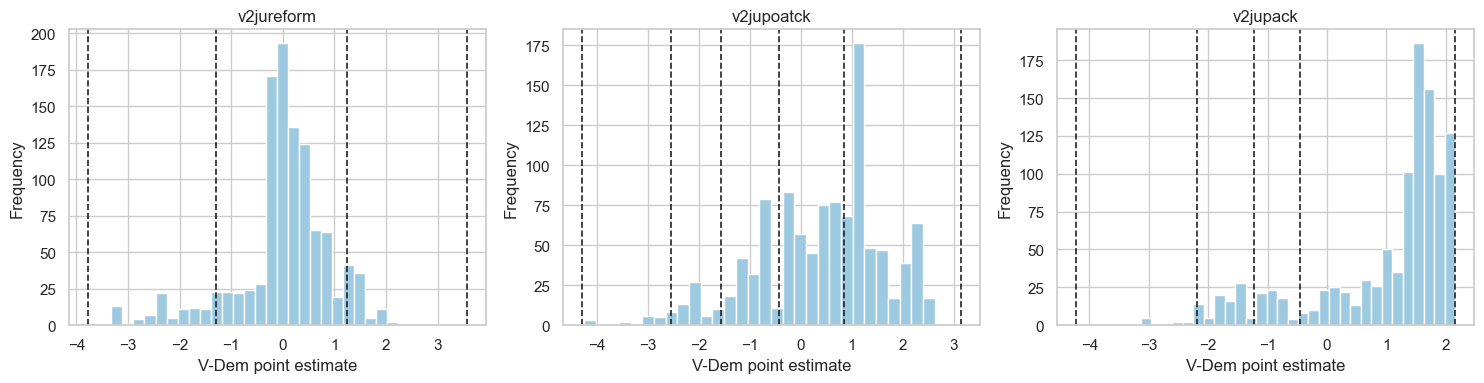

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)

for ax, col in zip(axes, judicial_pressure_cols):
    judicial_pressure[col].plot(kind="hist", bins=30, ax=ax, color="#9ecae1", edgecolor="white")

    specs = judicial_pressure_range_specs[col]
    boundaries = [specs[0]["low"]] + [spec["high"] for spec in specs]
    for boundary in boundaries:
        ax.axvline(boundary, color="#222222", linestyle="--", linewidth=1.2)

    ax.set_title(col)
    ax.set_xlabel("V-Dem point estimate")

plt.tight_layout()

In [17]:
judicial_pressure_by_court = (
    df.assign(**{col: judicial_pressure[col] for col in judicial_pressure_cols})
    .groupby("court_level", dropna=False)[judicial_pressure_cols]
    .agg(["count", "mean", "median", "std", "min", "max"])
)

judicial_pressure_by_court

v2jureform                                           v2jupoatck                                           v2jupack                              \
                    count      mean  median       std    min    max      count      mean  median       std    min    max    count      mean  median       std   
court_level                                                                                                                                                     
high                  296 -0.033716  0.0270  0.909623 -3.194  3.077        296  0.552361  0.9075  1.296685 -4.259  2.621      296  1.168949  1.4840  1.115363   
intl                    4  0.212250  0.3045  0.865922 -0.789  1.029          4  0.411250  0.8550  1.299181 -1.485  1.420        4 -0.129250 -0.5560  1.024580   
low                   325  0.268397  0.2280  0.765744 -3.321  1.870        325  0.353342  0.3350  1.036930 -3.110  2.621      325  1.138803  1.4840  0.942821   
mid                   205  0.191898  0.2280  0.538531 -2.868  2.345        205  0.549180  0.8940  0.957352 -4.259  2.621      205  1.492415  1.7330  0.774646   
oversight body         56 -0.248714 -0.1965  0.913062 -3.127  1.956         56  0.321589  0.5250  1.146668 -2.362  2.313       56  0.926554  1.4840  1.143705   
reg                   186 -0.482903 -0.1980  1.281442 -3.321  2.042        186  0.000962 -0.2270  1.660110 -4.259  2.422      186 -0.043102  0.0785  1.447588   
NaN                     3  0.554333  0.9850  1.016868 -0.607  1.285          3  0.724667  0.7120  0.396152  0.335  1.127        3 -0.222667  0.0990  0.599193   

                              
                  min    max  
court_level                   
high           -2.292  2.157  
intl           -0.794  1.389  
low            -2.100  2.157  
mid            -1.654  2.157  
oversight body -2.500  1.834  
reg            -3.131  1.959  
NaN            -0.914  0.147